# 3. Similarity Analysis

This notebook analyses semantic similarity between political manifestos from the Archelec corpus.

The objective is to compare a lexical baseline based on TF-IDF with a semantic representation based on sentence embeddings.

We focus on:
- TF-IDF similarity
- embedding-based similarity
- cosine similarity
- document ranking
- visualization of semantic relationships

In [1]:
from google.colab import files

uploaded = files.upload()

Saving legislatives (1).zip to legislatives (1).zip


## 3.1 Extracting the data

The dataset is uploaded as a zip file and extracted in the Colab environment.

In [2]:
import zipfile
import os

zip_path = "/content/legislatives (1).zip"  # change if your file has a different name

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed")

Extraction completed


In [3]:
os.listdir("/content")

['.config', 'legislatives (1).zip', 'text_files', 'sample_data']

## 3.2 Loading the manifestos

Each manifesto is stored as a `.txt` file.  
We load all documents into a pandas DataFrame.

In [4]:
import pandas as pd

folder = "/content/text_files/1988/legislatives"

data = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        file_path = os.path.join(folder, filename)

        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        data.append({
            "id": filename,
            "text": text
        })

df = pd.DataFrame(data)

print("Number of documents:", len(df))
df.head()

Number of documents: 3628


,id,text
0,EL176_L_1988_06_060_06_1_PF_01.txt,DEPARTEMENT DE L'OISE\n6ème CIRCONSCRIPTION\nC...
1,EL177_L_1988_06_095_07_1_PF_03.txt,LA FRANCE UNIE\nAVEC\nSciences Po / fonds CEVI...
2,EL175_L_1988_06_034_01_1_PF_04.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...
3,EL177_L_1988_06_095_03_2_PF_01.txt,Sciences Po / fonds CEVIPOF\nElections législa...
4,EL176_L_1988_06_059_12_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...


## 3.3 Text preprocessing

We clean the texts before computing vector representations.  
The cleaning step removes OCR noise, lowercases text, removes non-alphabetic characters, and normalizes spacing.

In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["id", "clean_text"]].head()

,id,clean_text
0,EL176_L_1988_06_060_06_1_PF_01.txt,departement de l oise ème circonscription comp...
1,EL177_L_1988_06_095_07_1_PF_03.txt,la france unie avec sciences po fonds cevipof ...
2,EL175_L_1988_06_034_01_1_PF_04.txt,sciences po fonds cevipof elections legislativ...
3,EL177_L_1988_06_095_03_2_PF_01.txt,sciences po fonds cevipof elections législativ...
4,EL176_L_1988_06_059_12_1_PF_03.txt,sciences po fonds cevipof elections legislativ...


## 3.4 Reducing the corpus for computational efficiency

Computing embeddings and pairwise similarity for thousands of documents can be computationally expensive.  
For this notebook, we use a sample of documents.

This keeps the analysis reproducible in Colab while still allowing us to observe meaningful similarity patterns.

In [6]:
# You can increase this number if Colab runs smoothly
sample_size = 500

df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

print("Sample size:", len(df_sample))
df_sample.head()

Sample size: 500


,id,text,clean_text
0,EL176_L_1988_06_059_02_1_PF_04.txt,ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988 2...,elections legislatives des et juin e circonscr...
1,EL176_L_1988_06_066_03_1_PF_02.txt,Majorité présidentielle\nLA FRANCE UNIE\nVOTEZ...,majorité présidentielle la france unie votez f...
2,EL175_L_1988_06_042_07_1_PF_01.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...,sciences po fonds cevipof republique française...
3,EL175_L_1988_06_035_02_1_PF_02.txt,O\nLA FRANCE UNIE\nAVEC\nEDMOND HERVE\nSUPPLEA...,o la france unie avec edmond herve suppleant j...
4,EL177_L_1988_06_075_03_1_PF_07.txt,7 raisons de voter pour le candidat du Front N...,raisons de voter pour le candidat du front nat...


## 3.5 TF-IDF baseline

TF-IDF is used as a lexical baseline.  
It represents documents according to word frequency and term specificity.

This method captures lexical overlap but does not directly model semantic meaning.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.9
)

tfidf_matrix = vectorizer.fit_transform(df_sample["clean_text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (500, 7704)


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_sim = cosine_similarity(tfidf_matrix)

print("TF-IDF similarity matrix shape:", tfidf_sim.shape)

TF-IDF similarity matrix shape: (500, 500)


## 3.6 Sentence embeddings

We now compute dense semantic representations using a pretrained Sentence Transformer model.

Unlike TF-IDF, sentence embeddings capture semantic relationships between texts, even when documents do not share the exact same vocabulary.

In [9]:
!pip install sentence-transformers

In [10]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df_sample["clean_text"].tolist()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32
)

print("Embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embeddings shape: (500, 384)


## 3.7 Embedding-based cosine similarity

We compute cosine similarity between document embeddings.  
This produces a matrix where each entry represents the semantic proximity between two manifestos.

In [11]:
emb_sim = cosine_similarity(embeddings)

print("Embedding similarity matrix shape:", emb_sim.shape)

Embedding similarity matrix shape: (500, 500)


## 3.8 Similarity heatmap

The heatmap provides a global view of semantic relationships between documents.  
Brighter areas indicate higher similarity.

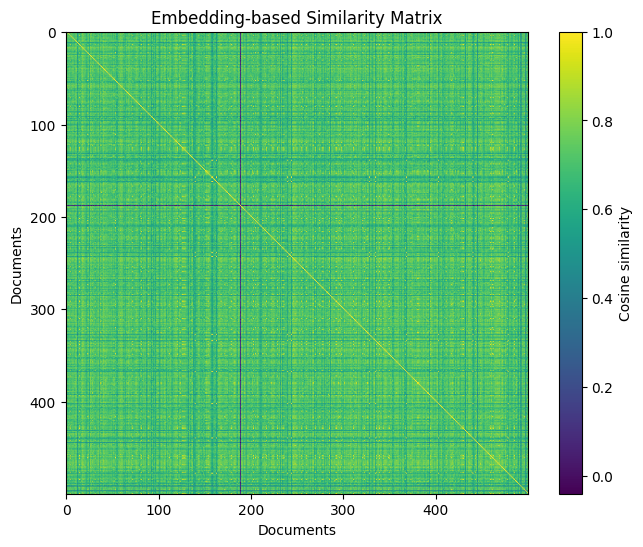

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(emb_sim, cmap="viridis")
plt.colorbar(label="Cosine similarity")
plt.title("Embedding-based Similarity Matrix")
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.show()

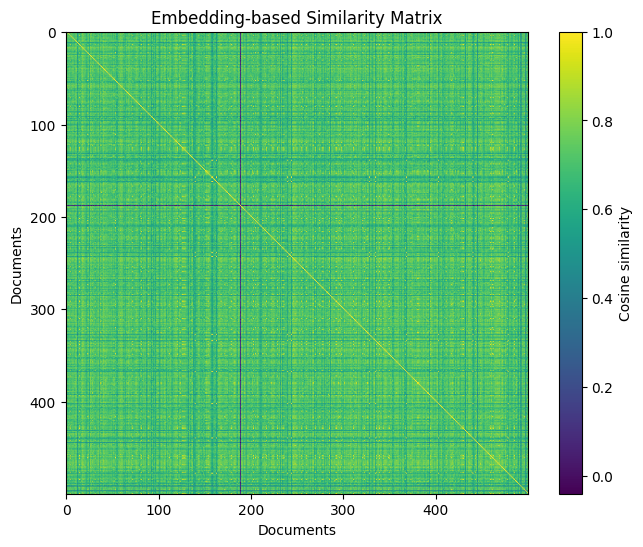

In [13]:
plt.figure(figsize=(8, 6))
plt.imshow(emb_sim, cmap="viridis")
plt.colorbar(label="Cosine similarity")
plt.title("Embedding-based Similarity Matrix")
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.savefig("similarity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.9 Ranking task

We formulate similarity analysis as a ranking task.

Given a query manifesto, we retrieve the top-k most similar documents according to cosine similarity.

In [14]:
def get_top_k(sim_matrix, query_idx, k=5):
    scores = sim_matrix[query_idx]
    top_indices = scores.argsort()[::-1][1:k+1]  # exclude the query itself
    return top_indices

In [15]:
query_idx = 0
top_k = 5

top_embedding_docs = get_top_k(emb_sim, query_idx, k=top_k)

print("Query document ID:")
print(df_sample.iloc[query_idx]["id"])

print("\nTop similar documents using embeddings:")
for rank, idx in enumerate(top_embedding_docs, start=1):
    print(f"{rank}. {df_sample.iloc[idx]['id']} | similarity = {emb_sim[query_idx, idx]:.4f}")

Query document ID:
EL176_L_1988_06_059_02_1_PF_04.txt

Top similar documents using embeddings:
1. EL176_L_1988_06_059_02_2_PF_02.txt | similarity = 0.9751
2. EL174_L_1988_06_014_06_1_PF_03.txt | similarity = 0.7774
3. EL175_L_1988_06_031_04_1_PF_01.txt | similarity = 0.7769
4. EL175_L_1988_06_030_05_2_PF_02.txt | similarity = 0.7717
5. EL174_L_1988_06_028_01_1_PF_04.txt | similarity = 0.7674


## 3.10 Inspecting retrieved documents

We inspect the query document and its nearest neighbors to evaluate whether the retrieved documents are semantically coherent.

In [16]:
print("QUERY DOCUMENT")
print("=" * 80)
print(df_sample.iloc[query_idx]["text"][:1000])

print("\n\nRETRIEVED DOCUMENTS")
print("=" * 80)

for rank, idx in enumerate(top_embedding_docs, start=1):
    print(f"\n--- Rank {rank}: {df_sample.iloc[idx]['id']} ---")
    print(df_sample.iloc[idx]["text"][:700])

QUERY DOCUMENT
ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988 2e CIRCONSCRIPTION
UNION du RASSEMBLEMENT et du CENTRE URC
Désiré VANBRABANT
Pierre RETUREAU
Sciences Po / fonds CEVIPOF
Je suis né à Ronchin le 29 avril 1935.
Je suis veuf ; j'ai un enfant, ce qui m'a amené à être durant huit années responsable de parents d'élèves. Je participe encore, pour un filleul, à l'association de parents d'un Lyçée Technique, j'ai aussi un petit fils.
Artisans en restauration de demeures anciennes, j'ai été pendant trois années, le Président de l'Umion Commerciale de Ronchin, avant d'en être le Président d'Honneur.
Je suis né à Angers et habite depuis 29 ans dans la métropole.
Marié, cinq enfants (8 petits enfants). Ingénieur commercial HEC, licencié en Droit, Docteur es - sciences - Eco
Actuellement retraité après avoir occupé des postes de direction dans différentes entreprises.
Conseiller municipal d'oposition à Villeneuve d'Ascq depuis 1983.
UNE EQUIPE COMPETENTE ET EXPERIMENTEE 0 A VOTRE SERVICE


## 3.11 Comparing TF-IDF and embeddings

We compare the top documents retrieved by TF-IDF and by embeddings.

TF-IDF retrieves documents based on lexical overlap, while embeddings retrieve documents based on semantic proximity.

In [17]:
top_tfidf_docs = get_top_k(tfidf_sim, query_idx, k=top_k)

print("Query document ID:")
print(df_sample.iloc[query_idx]["id"])

print("\nTop documents using TF-IDF:")
for rank, idx in enumerate(top_tfidf_docs, start=1):
    print(f"{rank}. {df_sample.iloc[idx]['id']} | similarity = {tfidf_sim[query_idx, idx]:.4f}")

print("\nTop documents using embeddings:")
for rank, idx in enumerate(top_embedding_docs, start=1):
    print(f"{rank}. {df_sample.iloc[idx]['id']} | similarity = {emb_sim[query_idx, idx]:.4f}")

Query document ID:
EL176_L_1988_06_059_02_1_PF_04.txt

Top documents using TF-IDF:
1. EL176_L_1988_06_059_02_2_PF_02.txt | similarity = 0.6907
2. EL175_L_1988_06_053_01_2_PF_01.txt | similarity = 0.1914
3. EL177_L_1988_06_094_03_1_PF_07.txt | similarity = 0.1648
4. EL177_L_1988_06_076_02_2_PF_01.txt | similarity = 0.1644
5. EL174_L_1988_06_028_03_1_PF_04.txt | similarity = 0.1607

Top documents using embeddings:
1. EL176_L_1988_06_059_02_2_PF_02.txt | similarity = 0.9751
2. EL174_L_1988_06_014_06_1_PF_03.txt | similarity = 0.7774
3. EL175_L_1988_06_031_04_1_PF_01.txt | similarity = 0.7769
4. EL175_L_1988_06_030_05_2_PF_02.txt | similarity = 0.7717
5. EL174_L_1988_06_028_01_1_PF_04.txt | similarity = 0.7674


In [18]:
tfidf_set = set(top_tfidf_docs)
embedding_set = set(top_embedding_docs)

overlap = tfidf_set.intersection(embedding_set)

print("Number of overlapping documents in top-k:", len(overlap))
print("Overlap ratio:", len(overlap) / top_k)

Number of overlapping documents in top-k: 1
Overlap ratio: 0.2


## 3.12 Interpretation of model comparison

A low overlap between TF-IDF and embedding rankings suggests that the two methods capture different types of similarity.

TF-IDF mainly captures shared vocabulary, while embeddings capture broader semantic relationships.

This supports the use of embeddings for political manifesto analysis, where similar ideas may be expressed with different words.

## 3.13 Dimensionality reduction

To visualize the embedding space, we project document embeddings into two dimensions using PCA.

This allows us to inspect whether documents form visible groups in semantic space.

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(embeddings)

df_sample["pca_1"] = pca_result[:, 0]
df_sample["pca_2"] = pca_result[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.08661243 0.06592446]


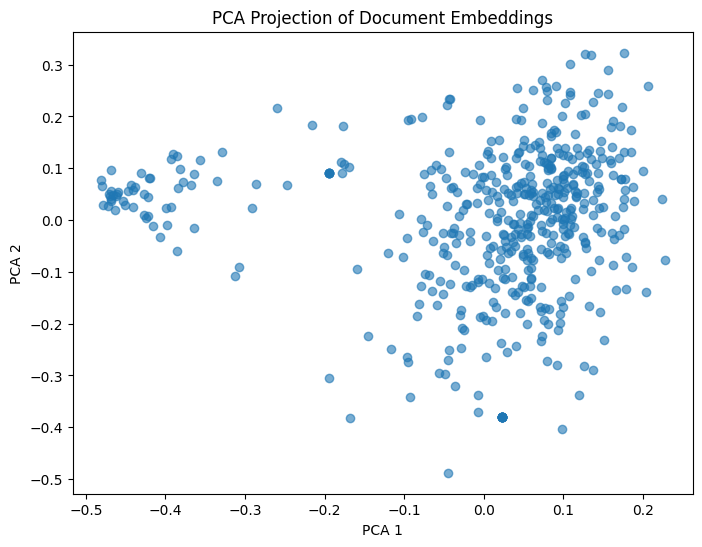

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(df_sample["pca_1"], df_sample["pca_2"], alpha=0.6)
plt.title("PCA Projection of Document Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

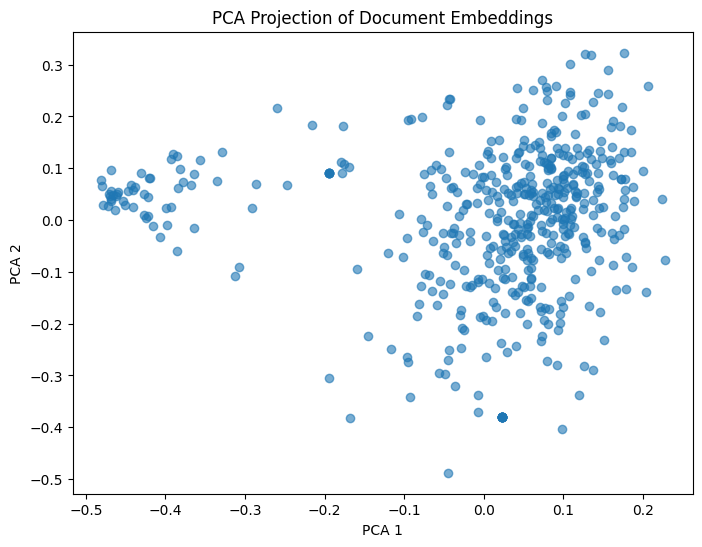

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(df_sample["pca_1"], df_sample["pca_2"], alpha=0.6)
plt.title("PCA Projection of Document Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.savefig("pca_embeddings.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.14 t-SNE visualization

t-SNE is used to obtain a nonlinear two-dimensional projection of document embeddings.

This visualization can reveal local clustering structures that may not appear clearly in PCA.

In [22]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate="auto",
    init="pca"
)

tsne_result = tsne.fit_transform(embeddings)

df_sample["tsne_1"] = tsne_result[:, 0]
df_sample["tsne_2"] = tsne_result[:, 1]

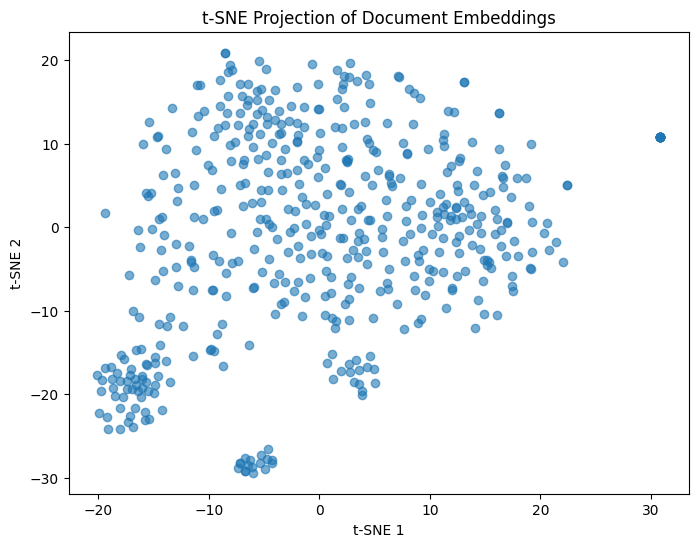

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(df_sample["tsne_1"], df_sample["tsne_2"], alpha=0.6)
plt.title("t-SNE Projection of Document Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

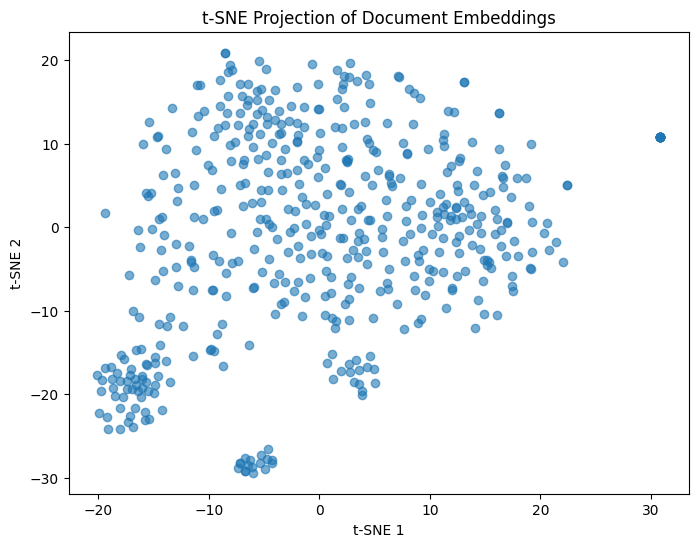

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(df_sample["tsne_1"], df_sample["tsne_2"], alpha=0.6)
plt.title("t-SNE Projection of Document Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.savefig("tsne_projection.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.15 Similarity score distribution

We inspect the distribution of pairwise similarity scores.  
This helps understand whether most documents are generally close to each other or whether similarity is concentrated among specific groups.

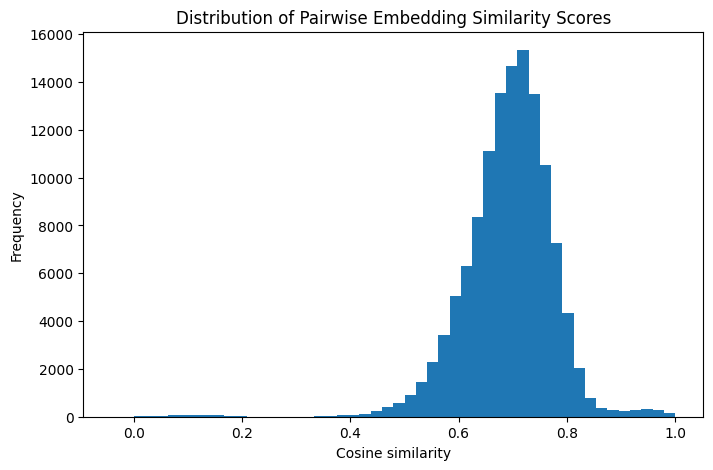

In [25]:
import numpy as np

# remove diagonal values equal to 1
sim_values = emb_sim[np.triu_indices_from(emb_sim, k=1)]

plt.figure(figsize=(8, 5))
plt.hist(sim_values, bins=50)
plt.title("Distribution of Pairwise Embedding Similarity Scores")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.show()

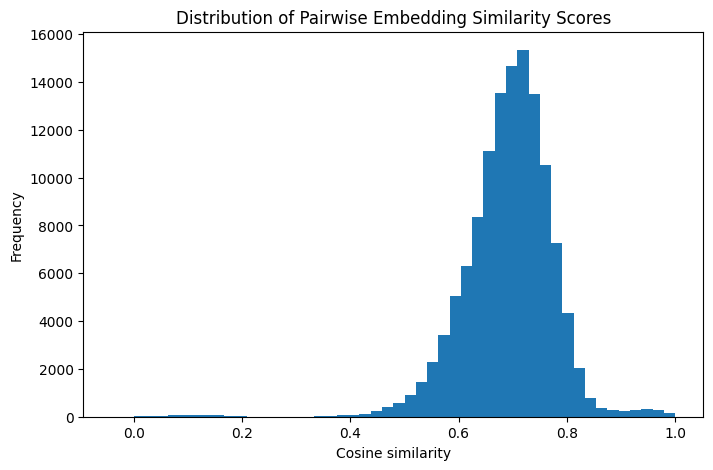

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(sim_values, bins=50)
plt.title("Distribution of Pairwise Embedding Similarity Scores")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.savefig("similarity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.16 Summary

This notebook compared lexical and semantic similarity methods.

The TF-IDF baseline captures similarity based on shared vocabulary, while embeddings capture broader semantic proximity between documents.

The ranking task shows how embeddings can retrieve contextually related manifestos, and the visualizations suggest structure in the embedding space.

These results motivate the use of transformer-based embeddings for analyzing political discourse.